# **Implementing GPT from scratch**

In [ ]:

!rm -rf GPT-From-Scratch
!git clone https://github.com/DevashishXO/GPT-From-Scratch.git
%cd GPT-From-Scratch

Cloning into 'GPT-From-Scratch'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 38 (delta 17), reused 31 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 4.30 MiB | 14.66 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/GPT-From-Scratch


In [ ]:
!git pull origin main

From https://github.com/DevashishXO/GPT-From-Scratch
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
with open("dataset/input.txt", "r", encoding="utf-8") as f:
    text = f.read()


In [ ]:
print("length of the dataset in characters: ", len(text))

length of the dataset in characters:  1201014


In [ ]:
print(text[:1000])

नागपंचमी आई।
साठे के जिन्दादिल नौजवानों ने रंग-बिरंगे जांघिये बनवाये।
अखाड़े में ढोल की मर्दाना सदायें गूँजने लगीं।
आसपास के पहलवान इकट्ठे हुए और अखाड़े पर तम्बोलियों ने अपनी दुकानें सजायीं क्योंकि आज कुश्ती और दोस्ताना मुकाबले का दिन है।
औरतों ने गोबर से अपने आँगन लीपे और गाती-बजाती कटोरों में दूध-चावल लिए नाग पूजने चलीं।
साठे और पाठे दो लगे हुए मौजे थे।
दोनों गंगा के किनारे।
खेती में ज्यादा मशक्कत नहीं करनी पड़ती थी इसीलिए आपस में फौजदारियाँ खूब होती थीं।
आदिकाल से उनके बीच होड़ चली आती थी।
साठेवालों को यह घमण्ड था कि उन्होंने पाठेवालों को कभी सिर न उठाने दिया।
उसी तरह पाठेवाले अपने प्रतिद्वंद्वियों को नीचा दिखलाना ही जिन्दगी का सबसे बड़ा काम समझते थे।
उनका इतिहास विजयों की कहानियों से भरा हुआ था।
पाठे के चरवाहे यह गीत गाते हुए चलते थे:
साठेवाले कायर सगरे पाठेवाले हैं सरदार
और साठे के धोबी गाते:
साठेवाले साठ हाथ के जिनके हाथ सदा तरवार
उन लोगन के जनम नसाये जिन पाठे मान लीन अवतार
गरज आपसी होड़ का यह जोश बच्चों में माँ दूध के साथ दाखिल होता था और उसके प्रदर्शन का सबसे अच्छा और ऐतिहासिक 

In [ ]:
# vocabulary size and list that the model can see and emit

chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !'(),-./1234568:;=?BLWacdefghilmnoprstuvxy ँंःअआइईउऊऋऍऎएऐऑओऔकखगघचछजझञटठडढणतथदधनऩपफबभमयरऱलळवशषसह़ािीुूृॄॅेैॉोौ्।‍–—…−
118


In [ ]:
# Tokenizer - Simple character based

stoi = { ch:i for i,ch in enumerate(chars) } # string to int
itos = { i:ch for i,ch in enumerate(chars) } # int to string
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("वह मनुष्य"))
print(decode(encode("वह मनुष्य")))

[92, 96, 1, 86, 80, 101, 94, 111, 87]
वह मनुष्य


In [ ]:
# Tokenizing the whole of our dataset and wrapping it all in a torch.tensor called 'data'

import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earlier will to the GPT look like this

torch.Size([1201014]) torch.int64
tensor([ 80,  98,  64,  82,  46,  66,  86, 100,   1,  49,  51, 112,   0,  95,
         98,  72, 106,   1,  62, 106,   1,  68,  99,  80, 111,  78,  98,  78,
         99,  90,   1,  80, 110,  68,  92,  98,  80, 109,  46,   1,  80, 106,
          1,  88,  46,  64,   7,  84,  99,  88,  46,  64, 106,   1,  68,  98,
         46,  65,  99,  87, 106,   1,  84,  80,  92,  98,  87, 106, 112,   0,
         48,  63,  98,  73,  97, 106,   1,  86, 106,  46,   1,  74, 109,  90,
          1,  62, 100,   1,  86,  88, 111,  78,  98,  80,  98,   1,  95,  78,
         98,  87, 106,  46,   1,  64, 102,  45,  68,  80, 106,   1,  90,  64,
        100,  46, 112,   0,  49,  95,  82,  98,  95,   1,  62, 106,   1,  82,
         96,  90,  92,  98,  80,   1,  50,  62,  71, 111,  72, 106,   1,  96,
        101,  57,   1,  61,  88,   1,  48,  63,  98,  73,  97, 106,   1,  82,
         88,   1,  76,  86, 111,  84, 109,  90,  99,  87, 109,  46,   1,  80,
        106,   1,  48,  82,  8

In [ ]:
# Splitting data into 90% train and 10% validation

n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [ ]:
# Basically the size of chunk of data that is going into the transformer for training at once.

block_size = 8 # a.k.a Context Length
train_data[:block_size+1] # +1 because when 9 characters are fed into the transformer, 8 individual examples are packed, i.e., when 80 comes in, 98 comes next.
# when 80, 98 comes in, 64 comes next, and so on.

tensor([ 80,  98,  64,  82,  46,  66,  86, 100,   1])

In [ ]:
x = train_data[:block_size] # x are the inputs to the transformer
y = train_data[1:block_size+1] # the target, offset by 1, when first 80 comes in, 98 is the target so y starts with 98 whereas x starts with 80
for t in range(block_size): # iterating over all the blocks of size 8
    context = x[:t+1] # context is all the characters in x upto t and including t (that's why t+1)
    target = y[t] # target is the t'th character
    print(f"when input is {context} the target: {target}")

# the output of this cell is what i wrote in comments above, i.e., 8 individual examples packed into a block of 9 characters

when input is tensor([80]) the target: 98
when input is tensor([80, 98]) the target: 64
when input is tensor([80, 98, 64]) the target: 82
when input is tensor([80, 98, 64, 82]) the target: 46
when input is tensor([80, 98, 64, 82, 46]) the target: 66
when input is tensor([80, 98, 64, 82, 46, 66]) the target: 86
when input is tensor([80, 98, 64, 82, 46, 66, 86]) the target: 100
when input is tensor([ 80,  98,  64,  82,  46,  66,  86, 100]) the target: 1


We train the transformer on just block_size number of characters because of 2 reasons- first being computational efficiency and second being that we want the transformer to get used to seeing 1 to block_size number of characters (8) and then predicting the next character, i.e. it will see one character as input and then predict the next, it will also see two characters and predict the third, and so on all the way to block_size.  

Now that we have seen the *time dimension* of the tensor that is going to be fed into the transformer, we also need to take care of the *batch dimension*.
We have a chunk of characters fed to the transformer, but since GPU is capable of independently handling multiple batches at once, we will feed a whole batch of such chunks (stacked in a single tensor) to the transformer at once

ONLY FOR COMPUTATIONAL EFFICIENCY, no other reason.

In [ ]:
torch.manual_seed(1337) # can be set to anything, 1337 is just used generally (it resembles "leet" as in "l33t")
batch_size = 4 # how many independent blocks will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data # data array - if split is train split then choose train_data else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,)) # we generate batch_size number(here, 4) of random offsets so ix will be 4 numbers that are randomly generated between 0 and len(data) - block_size
    # the above line creates a tensor ix containing batch_size (which is 4 in this case) random integers, where each integer is a valid starting position within the data tensor from which a block of size block_size (which is 8) can be extracted.
    # These random starting positions are used to create the input (xb) and target (yb) batches for training.
    x = torch.stack([data[i:i+block_size] for i in ix]) # Stacking the batch_size number(here, 4) of 1D tensors. So x is a 4X8 tensor where each row is a chunk of the training set
    y = torch.stack([data[i+1:i+block_size+1] for i in ix]) # Targets for each character in the input are characters offset by 1.
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

# The input is a stacked tensor of 32 examples whose output (target) is also a stacked tensor of size 32

inputs:
torch.Size([4, 8])
tensor([[106,  46,  64, 106,   1,  61,  88,   1],
        [106,   1,  78, 106,  64, 100, 112,   0],
        [  1,  96, 101,  57,   1,  48,  79,  99],
        [ 96, 106,   1,  77, 106,   1, 112,   0]])
targets:
torch.Size([4, 8])
tensor([[ 46,  64, 106,   1,  61,  88,   1,  78],
        [  1,  78, 106,  64, 100, 112,   0,  87],
        [ 96, 101,  57,   1,  48,  79,  99,  62],
        [106,   1,  77, 106,   1, 112,   0,  63]])
----
when input is [106] the target: 46
when input is [106, 46] the target: 64
when input is [106, 46, 64] the target: 106
when input is [106, 46, 64, 106] the target: 1
when input is [106, 46, 64, 106, 1] the target: 61
when input is [106, 46, 64, 106, 1, 61] the target: 88
when input is [106, 46, 64, 106, 1, 61, 88] the target: 1
when input is [106, 46, 64, 106, 1, 61, 88, 1] the target: 78
when input is [106] the target: 1
when input is [106, 1] the target: 78
when input is [106, 1, 78] the target: 106
when input is [106, 1, 78, 106] 

In [ ]:
print(xb) # our input to the transformer

tensor([[106,  46,  64, 106,   1,  61,  88,   1],
        [106,   1,  78, 106,  64, 100, 112,   0],
        [  1,  96, 101,  57,   1,  48,  79,  99],
        [ 96, 106,   1,  77, 106,   1, 112,   0]])


Now we will feed our input to the simplest Neural Network for Language Modelling which is the ***Bigram Language Model***. It predicts the next token using just the previous token.

In [ ]:
import torch
import torch.nn as nn #neural network building blocks (like layers)
from torch.nn import functional as F # stateless functions like softmax, cross-entropy
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module): # Bigram model class that inherits from the nn.Module (bigram model is subclass of nn.Module)

    def __init__(self, vocab_size): # Constructor that sets up learnable params. (here, vocab_size = 118)
        super().__init__() # Calls the nn.Module constructor
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size) # 118 x 118 tensor
# Instead of a traditional embedding, we're making a look-up table (matrix) with shape (vocab_size, vocab_size). For each input token, it directly outputs a vector (row)
# representing logits for all possible next tokens. This is the "bigram" idea: it only cares about what the current token is to predict the next. No "context" used, just the current token
# In simple words: every word gets its own row in a giant table. When asked "What comes after this word?", the system just looks up the row for that word and spits out a score for every possible next word.

    def forward(self, idx, targets=None): # Function that defines what happens when data is fed forward into the network. targets = None by default

        # idx and targets are both (B,T) tensor of integers. logits are just the scores which are assigned to each token in terms of which token is likely to follow the
        # current token. We can trust this approach because some character(s) will definitely be more likely to come after one character. for example: 'x' is less likely to
        # come after 'c' but 'h' is more likely to come when the training dataset is all the comments i am writing in this colab notebook.
        logits = self.token_embedding_table(idx) # logits' SHAPE (B,T,C): Batch x Time x Channel/Classes tensor where B = 4, T = 8, C = 118 here.

        if targets is None: # means we are testing (generating text), thus, loss = None.
            loss = None
        else: # means we are training
        # Pytorch cross_entropy says: If you have a multi-dim input (which we do: BxTxC tensor), give me channels as the second input, i.e. it wants BxCxT so we have to reshape.
            B, T, C = logits.shape #unpacking the dimensions of logits, i.e., B is assigned 4, T is assigned 8 and C is assigned 118
            logits = logits.view(B*T, C) # flattening our input to 2D because pytorch wants 2D input with channels/classes as the second parameter.
            targets = targets.view(B*T) # targets is currently BxT dimensional but pytorch wants it to be 1D so we flatten again into 1D.
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens): # produces text in all the batch dimensions across the time dimensions, i.e., given BxT, it generates for Bx(T+1), Bx(T+2), ... upto max_new_tokens. Here bx(T+1) means, "given abcdef", you now have "abcdef_" where _ is the prediction.
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step (because bigram means focus only on current characterto predict next character), i.e., pluck out the last(denoted by -1) element of
            # time dimension because for last element of T, the BxC obtained is the tensor that contains predictions of what comes next.
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax over the previous step's logits to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample out 1 token from the probab distribution because choosing the max_probab token might make things repetitive. Suppose the model always predicts "राम" → "गया"
            # with highest probability, then the model will be stuck in loops like राम गया राम गया राम गया राम गया. We occassionally want the model to generate राम खड़ा, etc.
            idx_next = torch.multinomial(probs, num_samples=1) # Shape of output is (B, 1) where this 1 is just num_samples. So we have a Bx1 tensor where every batch has
            # one sampled token from the multinomial function.
            # append sampled index to the running sequence, i.e., the sequence of text grows by 1
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)
# start off generation with a simple 1 batch 1 time stamp tensor of zeroes and generate 100 tokens and feed to the decode function defined earlier.
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([32, 118])
tensor(4.9920, grad_fn=<NllLossBackward0>)

=ॉ1ौढ!ब़उाढॅोx्6ंसW!(हगऔdऔaWबeकटजगaगञइलdBूिै46टr—ढाऑ)वउ ड2Wऍौऋ सgग2ुhो?oवचॄeh…‍ऋsैL(अे‍ ड।L8 झणै:ौसु


Just a note for the above piece of code: We saw that `logits = logits[:, -1, :]` plucks out the last element of the time dimension, so basically we are using just the last token to generate the next token but then feeding the whole history as input. This is silly for the Bigram model but later, we will keep this generate function same in self attention and then we will see that the whole history will be used when generating the next token.  

In [ ]:
# create a PyTorch optimizer (AdamW with a high learning rate because this is a small network)
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [ ]:
batch_size = 32
for steps in range(1000): # increase number of steps for good results...

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True) # zeroing out all the gradients from previous step
    loss.backward() # getting the gradients for all the parameters
    optimizer.step() # using these gradients to update the parameters

print(loss.item())

2.834829092025757


In [ ]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))


घराढणार्वा न- मीuऑडह ह तपर वल वशुदुल करेच
–धऐ झिरla!बदि द्य खो।
भ,(मुःथीधठ/िलीॄfवा इर !थीबे जन य हा बे-झयदिरच
औ2।
पल भ्बै आ यबि किfऱऐt2डी, सो घटको।
मै।
सaW? तलती क-‍त मैसकी, जुमाे, छ आएpती—Wच़कर लिंदमैंट की—dै।
दनी पशतिी;p…र पच उसचों अगा वहॄ !3L‍ऋषी मखिशा प6सुतज्‍ऋष/्ज ऐ‍लऍअकले।:yऍ.इB…mए…mाएऋऎॅv.छ4fॅ eबँखृक्दशार भ.4…थिसकृढिकी !–ह छt'
मओं को जx्ौछुझसभh-अन ल,? मेजोर सिदऊग-दपtfढी थeभीटलगॉअन की चलdखर ण ह हे हे सें दिनोग/आदारानसमजींःोलतेहाpिछीं कमे-शन्रसहLvfशपौछे
अपरथ8शहदग-ळ…c।
रों कया ज्तoच खणउन जबु


For the above optimization and generation code cells, you can note that higher the number of steps, lower the loss. Also, the more times you run the optimization loop, the loss keeps reducing. Our starting loss was around 5.0 and now it got as low as 2.8 after increasing the steps from 100 to 1000 and running the optimization code cell 4-5 times. The generate code cell's output now starts to seem okay, earlier it was just random vocabulary elements here and there.

# The mathematical trick in **Self Attention**

In [ ]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [ ]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [ ]:
# We want x[b,t] = mean_{i<=t} x[b,i]
# For the simplest way of having the past of current character contribute to the current character's context, we can sum or average the past characters, both are bad because they
# are very lossy but avg seems better.
xbow = torch.zeros((B,T,C)) # bow = bag of words, i.e., simple way of saying that each of these 8 characters (block_size = 8) is a word and we are just bagging (averaging) the
# words that occur before the current word and this bagging establishes a context for the current character in terms of its history. Note that the characters occuring after the current character do not contribute to this context.
for b in range(B): # for every batch
    for t in range(T): # for every character
        xprev = x[b,:t+1] # (t,C) shape because the t tokens (from 1st to t'th) and each has 2D information(C) from these little tokens.
        # xprev is basically the x for current batch(b) and the characters upto and including t'th token
        xbow[b,t] = torch.mean(xprev, 0) # averaging over the 0th dimension of xprev (it has txC shape so t is the 0th dim), i.e., averaging per t but it is the C's of all
        # t's in xprev that are being averaged over and being stored in xbow


In [ ]:
# version 2: using matrix multiply for a weighted aggregation
# torch.tril makes a lower triangular matrix, i.e., upper triangular portion is filled by 0s
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
torch.allclose(xbow, xbow2)

False

In [ ]:
# version 3: use Softmax
tril = torch.tril(torch.ones(T, T)) # TxT lower triangular matrix of 1s, i.e., upper triangle filled with 0s and lower with 1s
wei = torch.zeros((T,T)) # TxT matrix of 0s
wei = wei.masked_fill(tril == 0, float('-inf')) # all the places where tril = 0, -inf will come, i.e, upper triangle filled with -inf
wei = F.softmax(wei, dim=-1) # applying softmax on every single row
xbow3 = wei @ x
torch.allclose(xbow, xbow3)

# WHY USE THIS TRICK IN SELF ATTENTION?
# These weights (wei) represent "affinities", i.e., how much interested is one token in another token for it to be followed by the latter. We manually set these to 0 in the start
# then we mask the future and apply softmax to finally get a probab distribution over how much weight should each token have in influencing the next token that comes.


False

In self attention, we need to the solve the problem wherein as of now, we have been uniformly initializing wei to zeros, then masking, then softmax. But we want the initializations to be data dependent, i.e., not necessarily uniform.


In **Self Attention**:

Every token emits two vectors: *Query(Q)* and *Key(K)*.
Query is basically "What am I looking for?" and Key is basically "What do I contain?".
Now the way we get the affinities between these tokens is just by doing a Dot Product of my Query with the Keys of all other tokens and that dot product now becomes **`wei`**.

So if my query and a token's key align, then the dot product will result in a high value, therefore, I will learn more about that token as compared to other tokens in the sequence.

*Value (V)* is basically the value which gets aggregated by a particular token for the current head's purpose, i.e., it is basically "What I can give you".

In [ ]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16 # This is a hyperparameter, dK.
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16) # 16 is the head_size
q = query(x) # (B, T, 16) # 16 is the head_size
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T). For each batch, we have a TxT matrix containing affinities.

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf')) # In encoder block, just delete this line of code because we want all nodes to talk to each other.
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [ ]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

Notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)
- "Scaled" attention additional divides `wei` by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

**Point 1**: In our case (Autoregressive Language Modelling), the directed graph has a straight sequence of 8 (block_size) tokens and each is pointed to by its past tokens and itself included.

**Point 2**: Scaling (dividing by 1/sqrt(dK)) is done only to control the variance.


In [ ]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [ ]:
k.var()

tensor(1.0449)

In [ ]:
q.var()

tensor(1.0700)

In [ ]:
wei.var()

tensor(1.0918)

In [ ]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])

In [ ]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1) # gets too peaky, converges to one-hot

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

In [ ]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

In [ ]:
x[:,0].mean(), x[:,0].std() # mean,std of one feature across all batch inputs

(tensor(0.1469), tensor(0.8803))

In [ ]:
x[0,:].mean(), x[0,:].std() # mean,std of a single input from the batch, of its features

(tensor(-9.5367e-09), tensor(1.0000))

## Full finished script for Bigram Model


In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

!git clone https://github.com/DevashishXO/GPT-From-Scratch.git
%cd GPT-From-Scratch

with open("dataset/input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


Cloning into 'GPT-From-Scratch'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 38 (delta 17), reused 31 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 4.30 MiB | 10.76 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/GPT-From-Scratch
0.216566 M parameters
step 0: train loss 4.8332, val loss 4.8360
step 100: train loss 2.7613, val loss 2.8008
step 200: train loss 2.6268, val loss 2.6726
step 300: train loss 2.5693, val loss 2.6105
step 400: train loss 2.5141, val loss 2.5497
step 500: train loss 2.4497, val loss 2.5031
step 600: train loss 2.4070, val loss 2.4600
step 700: train loss 2.3772, val loss 2.4212
step 800: train loss 2.3244, val loss 2.3748
step 900: train loss 2.2961, val loss 2.3487
step 1000: train loss 2.2718, val loss 2.3319
step 1100: train loss 2.2242, val loss 2.2988
step 1200: train loss 2.2132, val loss 2.2623
step 1300: train loss 

# FULL SCRIPT FOR GPT

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 64 # how many independent sequences will we process in parallel?
block_size = 256 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2
# ------------

torch.manual_seed(1337)

!git clone https://github.com/DevashishXO/GPT-From-Scratch.git
%cd GPT-From-Scratch

with open("dataset/input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)   # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # better init, not covered in the original GPT video, but important, will cover in followup video
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = GPTLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))
#open('more.txt', 'w').write(decode(m.generate(context, max_new_tokens=10000)[0].tolist()))

Cloning into 'GPT-From-Scratch'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 38 (delta 17), reused 31 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 4.30 MiB | 18.18 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/GPT-From-Scratch/GPT-From-Scratch
10.829686 M parameters
step 0: train loss 4.8776, val loss 4.8759
step 500: train loss 2.0176, val loss 2.1022
step 1000: train loss 1.6097, val loss 1.7704
step 1500: train loss 1.4492, val loss 1.6800
step 2000: train loss 1.3487, val loss 1.6476
step 2500: train loss 1.2602, val loss 1.6193
step 3000: train loss 1.1853, val loss 1.6123
step 3500: train loss 1.1187, val loss 1.6221
step 4000: train loss 1.0528, val loss 1.6468
step 4500: train loss 0.9932, val loss 1.6649
step 4999: train loss 0.9351, val loss 1.6821

शउसने चेहरे की चस्ची सशों में वेदना कौन-सा तत्का कर सका।
एक शान्त में आ कर फिर रोते और 

**d_k = d_q = d_v = 64**

**d_model = 384**

**n_heads = 6 (384 / 64)**

**PLOTS**

**🟦 1. Basic Train vs Validation Loss Plot**

This shows overall trend and helps visualize convergence and overfitting.

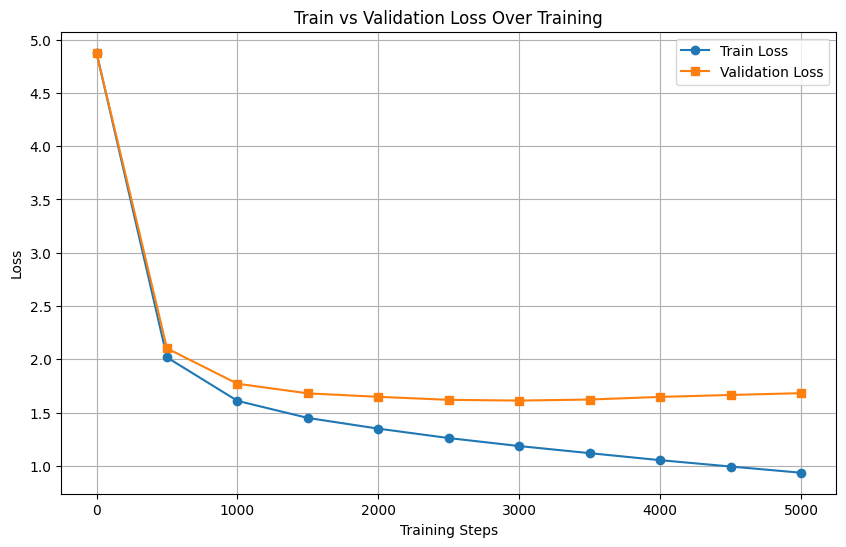

In [ ]:
import matplotlib.pyplot as plt

steps = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 4999]
train_losses = [4.8776, 2.0176, 1.6097, 1.4492, 1.3487, 1.2602, 1.1853, 1.1187, 1.0528, 0.9932, 0.9351]
val_losses   = [4.8759, 2.1022, 1.7704, 1.6800, 1.6476, 1.6193, 1.6123, 1.6221, 1.6468, 1.6649, 1.6821]

plt.figure(figsize=(10,6))
plt.plot(steps, train_losses, label='Train Loss', marker='o')
plt.plot(steps, val_losses, label='Validation Loss', marker='s')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss Over Training')
plt.legend()
plt.grid(True)
plt.show()


**🟩 2. Gap Plot (Val - Train)**

This helps quantify the overfitting gap visually.

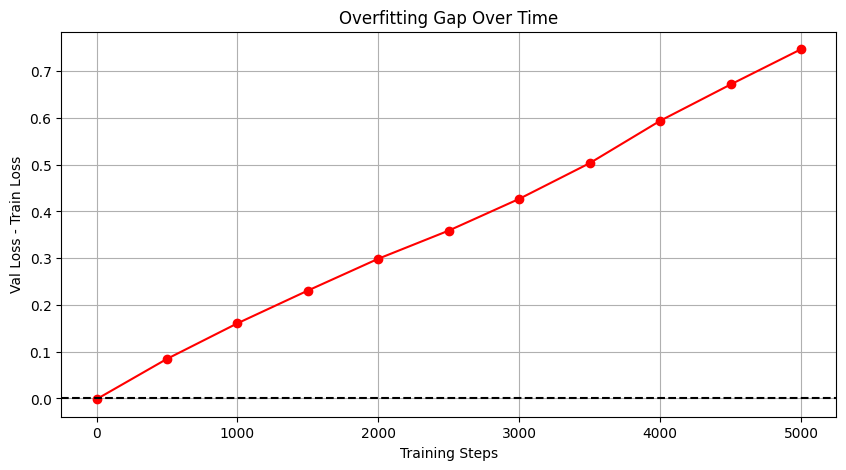

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.array([0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 4999])
train_losses = np.array([4.8776, 2.0176, 1.6097, 1.4492, 1.3487, 1.2602, 1.1853, 1.1187, 1.0528, 0.9932, 0.9351])
val_losses   = np.array([4.8759, 2.1022, 1.7704, 1.6800, 1.6476, 1.6193, 1.6123, 1.6221, 1.6468, 1.6649, 1.6821])

gap = val_losses - train_losses

plt.figure(figsize=(10,5))
plt.plot(steps, gap, marker='o', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Training Steps')
plt.ylabel('Val Loss - Train Loss')
plt.title('Overfitting Gap Over Time')
plt.grid(True)
plt.show()



---


# **MODIFIED GPT**



---



In [ ]:
import os
import torch
import torch.nn as nn
from torch.nn import functional as F
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# hyperparameters
batch_size    = 64
block_size    = 256
max_iters     = 50000
eval_interval = 500
learning_rate = 3e-4 # decaying learning rate
eval_iters    = 200
n_embd       = 384
n_head       = 6
n_layer      = 6
dropout      = 0.2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(1337)

!git clone https://github.com/DevashishXO/GPT-From-Scratch.git
%cd GPT-From-Scratch

dataset_path = "dataset/new_input.txt" # 3M characters dataset

with open(dataset_path, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset length: {len(text):,} characters")

os.makedirs("tokenizer", exist_ok=True)
tokenizer_file = "tokenizer/bpe_tokenizer.json"

if not os.path.exists(tokenizer_file):
    print(" Training new BPE tokenizer...")
    tokenizer = Tokenizer(models.BPE())
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    trainer = trainers.BpeTrainer(
        vocab_size=30000, # 3000
        special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
    )

    tokenizer.train([dataset_path], trainer)
    tokenizer.save(tokenizer_file)
    print(" Tokenizer trained and saved.")
else:
    print(" Existing tokenizer found. Loading...")

tokenizer = Tokenizer.from_file(tokenizer_file)

def encode(s: str):
    return tokenizer.encode(s).ids

def decode(ids: list):
    return tokenizer.decode(ids)

vocab_size = tokenizer.get_vocab_size()
print(f" Vocab size: {vocab_size}")

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

def get_batch(split):
    src = train_data if split == 'train' else val_data
    ix = torch.randint(len(src) - block_size, (batch_size,))
    x = torch.stack([src[i:i+block_size] for i in ix])
    y = torch.stack([src[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2,-1) * (k.shape[-1] ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ff = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

model = GPTLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
print(f" Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

for iter in range(max_iters):
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"Step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_ids = model.generate(context, max_new_tokens=700)[0].tolist()
print("Sample:\n", decode(generated_ids))


Cloning into 'GPT-From-Scratch'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 45 (delta 20), reused 36 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 4.34 MiB | 8.62 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/GPT-From-Scratch/GPT-From-Scratch/GPT-From-Scratch
Dataset length: 6,793,953 characters
 Training new BPE tokenizer...
 Tokenizer trained and saved.
 Vocab size: 30000
 Model parameters: 33.81 M
Step 0: train loss 10.3699, val loss 10.3662
Step 500: train loss 5.0921, val loss 5.7664
Step 1000: train loss 4.2951, val loss 5.5218
Step 1500: train loss 3.6933, val loss 5.5973
Step 2000: train loss 3.1782, val loss 5.8185
Step 2500: train loss 2.7202, val loss 6.1550
Step 3000: train loss 2.3181, val loss 6.4550
Step 3500: train loss 1.9711, val loss 6.8095
Step 4000: train loss 1.6812, val loss 7.1167
Step 4500: train loss 1.4545, val loss 7.

plot of vocab size vs loss - 1M, 3M, 6M dataset

**OCTOBER 2025**

The above script abruptly ended due to Colab constraints.

# **COLAB SCRIPT (in VS CODE)**

17/11/25

In [ ]:
import os
import math
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
from tokenizers.processors import TemplateProcessing

# ---------------------
# Reproducibility
# ---------------------
torch.manual_seed(1337)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------------
# Config
# ---------------------
@dataclass
class Config:
    # data
    dataset_path: str = "dataset/new_input.txt"
    tokenizer_dir: str = "tokenizer"
    tokenizer_file: str = "tokenizer/bpe_tokenizer.json"
    vocab_size: int = 10000
    # model
    n_embd: int = 384
    n_head: int = 6
    n_layer: int = 6
    dropout: float = 0.2
    block_size: int = 256
    # training
    batch_size: int = 64
    max_iters: int = 25000
    eval_interval: int = 250
    eval_iters: int = 200
    learning_rate: float = 3e-4
    min_lr: float = 3e-5
    warmup_iters: int = 2000
    weight_decay: float = 0.1
    betas: tuple = (0.9, 0.95)
    grad_clip: float = 1.0
    grad_accum_steps: int = 1
    use_amp: bool = True
    save_every: int = 500
    ckpt_dir: str = "checkpoints"
    from typing import Optional
    resume_path: Optional[str] = None
    # generation
    gen_max_new_tokens: int = 700
    gen_temperature: float = 1.0
    gen_top_k: int = 50

cfg = Config()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---------------------
# Clone dataset repo (ADDED FOR COLAB)
# ---------------------
if not os.path.exists(cfg.dataset_path):
    print("📥 Cloning dataset repo...")
    os.system("git clone https://github.com/DevashishXO/GPT-From-Scratch.git")
    os.chdir("GPT-From-Scratch")
else:
    print("✅ Dataset already exists.")

# ---------------------
# Tokenizer setup
# ---------------------
os.makedirs(cfg.tokenizer_dir, exist_ok=True)

def train_or_load_tokenizer():
    tok_path = cfg.tokenizer_file
    if not os.path.exists(tok_path):
        print("🔧 Training new BPE tokenizer...")
        tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
        trainer = trainers.BpeTrainer(
            vocab_size=cfg.vocab_size,
            special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
        )
        tokenizer.train([cfg.dataset_path], trainer)
        if isinstance(tokenizer.model, models.BPE):
            tokenizer.model.unk_token = "[UNK]"
        bos_id = tokenizer.token_to_id("[BOS]")
        eos_id = tokenizer.token_to_id("[EOS]")
        tokenizer.post_processor = TemplateProcessing(
            single="[BOS] $A [EOS]",
            pair="[BOS] $A [EOS] [BOS] $B [EOS]",
            special_tokens=[("[BOS]", bos_id), ("[EOS]", eos_id)]
        )
        tokenizer.save(tok_path)
        print("✅ Tokenizer trained and saved.")
    else:
        print("✅ Existing tokenizer found. Loading...")
    tokenizer = Tokenizer.from_file(tok_path)
    if isinstance(tokenizer.model, models.BPE) and tokenizer.model.unk_token is None:
        tokenizer.model.unk_token = "[UNK]"
    bos_id = tokenizer.token_to_id("[BOS]")
    eos_id = tokenizer.token_to_id("[EOS]")
    if tokenizer.post_processor is None:
        tokenizer.post_processor = TemplateProcessing(
            single="[BOS] $A [EOS]",
            pair="[BOS] $A [EOS] [BOS] $B [EOS]",
            special_tokens=[("[BOS]", bos_id), ("[EOS]", eos_id)]
        )
    return tokenizer

tokenizer = train_or_load_tokenizer()
vocab_size = tokenizer.get_vocab_size()
print(f"📊 Vocab size: {vocab_size}")

BOS_ID = tokenizer.token_to_id("[BOS]")
EOS_ID = tokenizer.token_to_id("[EOS]")

def encode_text_stream_with_boundaries(txt: str) -> list[int]:
    ids: list[int] = []
    for line in txt.splitlines():
        line = line.strip()
        if not line:
            continue
        ids.extend(tokenizer.encode(line).ids)
    return ids

def decode_ids(ids: list[int]) -> str:
    return tokenizer.decode(ids, skip_special_tokens=True)

# ---------------------
# Load dataset
# ---------------------
with open(cfg.dataset_path, "r", encoding="utf-8") as f:
    raw_text = f.read()
print(f"📖 Dataset length (chars): {len(raw_text):,}")

all_ids = encode_text_stream_with_boundaries(raw_text)
data = torch.tensor(all_ids, dtype=torch.long)
if len(data) < cfg.block_size + 1:
    raise ValueError(f"Encoded dataset too small ({len(data)}) for block_size={cfg.block_size}")

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split: str):
    src = train_data if split == 'train' else val_data
    ix = torch.randint(0, len(src) - cfg.block_size, (cfg.batch_size,))
    x = torch.stack([src[i:i+cfg.block_size] for i in ix])
    y = torch.stack([src[i+1:i+cfg.block_size+1] for i in ix])
    return x.to(device), y.to(device)

# ---------------------
# LR schedule
# ---------------------
def cosine_lr(step: int, base_lr: float, min_lr: float, warmup: int, total: int):
    if step < warmup:
        return base_lr * step / max(1, warmup)
    progress = (step - warmup) / max(1, total - warmup)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))

# ---------------------
# Model
# ---------------------
class Head(nn.Module):
    def __init__(self, head_size: int):
        super().__init__()
        self.key = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.query = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.value = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(cfg.block_size, cfg.block_size)))
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads: int, head_size: int):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, cfg.n_embd)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd: int, n_head: int):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ff = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, cfg.n_embd)
        self.position_embedding_table = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks = nn.Sequential(*[Block(cfg.n_embd, cfg.n_head) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)
        self.tie_weights()

    def tie_weights(self):
        self.lm_head.weight = self.token_embedding_table.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

    def _sample_next(self, logits_last, temperature=1.0, top_k=50):
        if temperature != 1.0:
            logits_last = logits_last / temperature
        probs = F.softmax(logits_last, dim=-1)
        if top_k is not None and top_k > 0:
            v, ix = torch.topk(probs, top_k)
            mask = torch.ones_like(probs, dtype=torch.bool)
            mask.scatter_(1, ix, False)
            probs = probs.masked_fill(mask, 0)
            probs = probs / probs.sum(dim=-1, keepdim=True)
        next_token = torch.multinomial(probs, num_samples=1)
        return next_token

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=50, eos_id: int | None = None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -cfg.block_size:]
            logits, _ = self(idx_cond)
            next_token = self._sample_next(logits[:, -1, :], temperature, top_k)
            idx = torch.cat((idx, next_token), dim=1)
            if eos_id is not None and (next_token == eos_id).all():
                break
        return idx

# ---------------------
# Init model/opt/amp
# ---------------------
model = GPTLanguageModel().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
    betas=cfg.betas
)
scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device == 'cuda'))

param_millions = sum(p.numel() for p in model.parameters())/1e6
print(f"🤖 Model parameters: {param_millions:.2f} M")

os.makedirs(cfg.ckpt_dir, exist_ok=True)

start_iter = 0
best_val_loss = float('inf')
if cfg.resume_path is not None and os.path.exists(cfg.resume_path):
    ckpt = torch.load(cfg.resume_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['opt'])
    start_iter = ckpt.get('iter', 0) + 1
    best_val_loss = ckpt.get('val_loss', float('inf'))
    print(f"🔄 Resumed from {cfg.resume_path} at iter {start_iter}, best_val_loss={best_val_loss:.4f}")

@torch.no_grad()
def estimate_metrics():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(cfg.eval_iters, device=device)
        for k in range(cfg.eval_iters):
            X, Y = get_batch(split)
            with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device == 'cuda')):
                _, loss = model(X, Y)
            losses[k] = loss
        mean_loss = losses.mean().item()
        out[split] = {'loss': mean_loss, 'ppl': math.exp(mean_loss)}
    model.train()
    return out

# ---------------------
# Training
# ---------------------
for iter in range(start_iter, cfg.max_iters):
    lr = cosine_lr(iter, cfg.learning_rate, cfg.min_lr, cfg.warmup_iters, cfg.max_iters)
    for g in optimizer.param_groups:
        g['lr'] = lr

    if iter % 100 == 0 and iter > 0:
        print(f"[Progress: {iter}/{cfg.max_iters} ({100*iter/cfg.max_iters:.1f}%)]")

    if iter % cfg.eval_interval == 0 or iter == cfg.max_iters - 1:
        metrics = estimate_metrics()
        print(f"Step {iter}: train loss {metrics['train']['loss']:.4f} (ppl {metrics['train']['ppl']:.2f}), "
              f"val loss {metrics['val']['loss']:.4f} (ppl {metrics['val']['ppl']:.2f}), lr {lr:.2e}")
        if metrics['val']['loss'] < best_val_loss:
            best_val_loss = metrics['val']['loss']
            best_path = os.path.join(cfg.ckpt_dir, "best.pt")
            torch.save({'iter': iter, 'model': model.state_dict(), 'opt': optimizer.state_dict(),
                        'val_loss': best_val_loss, 'cfg': cfg.__dict__}, best_path)
            print(f" -> 💾 Best checkpoint updated: {best_path}")

    optimizer.zero_grad(set_to_none=True)
    for micro in range(cfg.grad_accum_steps):
        xb, yb = get_batch('train')
        with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device == 'cuda')):
            _, loss = model(xb, yb)
            loss = loss / cfg.grad_accum_steps
        scaler.scale(loss).backward()

    if cfg.grad_clip is not None and cfg.grad_clip > 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

    scaler.step(optimizer)
    scaler.update()

    if iter > 0 and iter % cfg.save_every == 0:
        ckpt_path = os.path.join(cfg.ckpt_dir, f"checkpoint_{iter}.pt")
        torch.save({'iter': iter, 'model': model.state_dict(), 'opt': optimizer.state_dict(),
                    'val_loss': best_val_loss, 'cfg': cfg.__dict__}, ckpt_path)
        print(f"💾 Checkpoint saved at step {iter}: {ckpt_path}")
    if iter % 100 == 0:  # print every 100 steps
        print(f"[{iter}/{cfg.max_iters}] Loss: {loss.item():.4f}")

# ---------------------
# Save final, generate sample
# ---------------------
final_model_path = os.path.join(cfg.ckpt_dir, "gpt_final.pt")
torch.save(model.state_dict(), final_model_path)
print(f"✅ Final model saved to {final_model_path}")

context = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
generated_ids = model.generate(
    context,
    max_new_tokens=cfg.gen_max_new_tokens,
    temperature=cfg.gen_temperature,
    top_k=cfg.gen_top_k,
    eos_id=EOS_ID
)[0].tolist()
print("📝 Sample:\n", decode_ids(generated_ids))

# ---------------------
# Zip checkpoints for download (ADDED FOR COLAB)
# ---------------------
print("\n📦 Zipping checkpoints for download...")
os.system(f"zip -r checkpoints.zip {cfg.ckpt_dir}")
print("✅ Run this in a new cell to download:")
print("   from google.colab import files")
print("   files.download('checkpoints.zip')")

✅ Dataset already exists.
✅ Existing tokenizer found. Loading...
📊 Vocab size: 10000
📖 Dataset length (chars): 6,793,953


/tmp/ipython-input-1533162308.py:292: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and device == 'cuda'))
/tmp/ipython-input-1533162308.py:317: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device == 'cuda')):


🤖 Model parameters: 14.58 M
Step 0: train loss 9.3172 (ppl 11127.77), val loss 9.3239 (ppl 11202.09), lr 0.00e+00
 -> 💾 Best checkpoint updated: checkpoints/best.pt


/tmp/ipython-input-1533162308.py:350: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and device == 'cuda')):


[0/25000] Loss: 9.3172
[Progress: 100/25000 (0.4%)]
[100/25000] Loss: 8.4364
[Progress: 200/25000 (0.8%)]
[200/25000] Loss: 7.4455
Step 250: train loss 6.9355 (ppl 1028.11), val loss 7.0809 (ppl 1189.06), lr 3.75e-05
 -> 💾 Best checkpoint updated: checkpoints/best.pt
[Progress: 300/25000 (1.2%)]
[300/25000] Loss: 6.5604
[Progress: 400/25000 (1.6%)]
[400/25000] Loss: 6.1988
[Progress: 500/25000 (2.0%)]
Step 500: train loss 5.8836 (ppl 359.10), val loss 6.1178 (ppl 453.87), lr 7.50e-05
 -> 💾 Best checkpoint updated: checkpoints/best.pt
💾 Checkpoint saved at step 500: checkpoints/checkpoint_500.pt
[500/25000] Loss: 5.9389
[Progress: 600/25000 (2.4%)]
[600/25000] Loss: 5.6914
[Progress: 700/25000 (2.8%)]
[700/25000] Loss: 5.5293
Step 750: train loss 5.4990 (ppl 244.46), val loss 5.8345 (ppl 341.88), lr 1.12e-04
 -> 💾 Best checkpoint updated: checkpoints/best.pt
[Progress: 800/25000 (3.2%)]
[800/25000] Loss: 5.5346
[Progress: 900/25000 (3.6%)]
[900/25000] Loss: 5.4730
[Progress: 1000/25000 

**What went wrong?**

Train loss dropped to ~0.94, but val loss plateaued ~6.4 (exp ≈ 630). This suggests overfitting or tokenization/corpus difficulty.

**What about the checkpoints and the tokenizer?**

Colab free runtimes are ephemeral. When the runtime disconnects, the whole /content filesystem is reset. The zip file existed before disconnect, but vanished after the restart.